# Extract phases from solutions

Created 05/03/2026

Objectives:
* Evalute the index from [this paper](https://doi.org/10.1063/5.0055996) on the qudit cluster chain. Should be faster than manually evaluating all the time.

# Package imports

In [2]:
import sys

In [3]:
sys.path.append("../../")

In [4]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [5]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

# Load data

In [6]:
DATA_DIR = r"../../data/qudit_cluster_chain_d_7_L_30.h5"

In [7]:
with h5py.File(DATA_DIR, 'r') as f:
    psi = hdf5_io.load_from_hdf5(f)

# Check expectations

In [10]:
Z_expectation_values = psi.expectation_value('Z')

In [11]:
Z_expectation_values.shape

(30,)

In [12]:
Z_expectation_values

array([1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 0.6234898+0.78183148j,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       0.6234898+0.78183148j, 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ,
       1.       +0.j        , 1.       +0.j        ])

In [13]:
psi.chi

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

# Definitions

In [26]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [27]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [28]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [29]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites):
    q_top = quimb_psi.copy(deep=True)
    for i, s in symmetry_site_pairs:
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    
    indices_to_map = list(chain(
        range(leftmost_symmetry_site-num_boundary_sites, leftmost_symmetry_site),
        range(leftmost_symmetry_site+num_symmetry_sites, leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites)
    ))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites)),
        'middle': list(range(leftmost_symmetry_site, leftmost_symmetry_site+num_symmetry_sites)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )

    return tnc

In [30]:
def generate_rdm_from_tenpy_psi(mps_psi, symmetry_site_pairs,
    leftmost_symmetry_site, num_symmetry_sites, num_boundary_sites):
    
    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())
    
    q1 = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )
    
    problem_rdm = generate_problem_rdm(
        q1,
        symmetry_site_pairs,
        left_most_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    return problem_rdm

## SPT extraction functions

In [31]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [32]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [33]:
e, a, b, c = symmetry_labels

In [34]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [35]:
"""
Old function

def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    full_circ = (
        u_g
        .gate_lower_with_op_lazy(u_h)
        .gate_lower_with_op_lazy(u_gh.H)
    )

    t = (rho & full_circ)

    out = t.trace()

    return (out/(np.abs(out)), np.abs(out))
"""

'\nOld function\n\ndef get_proj_rep_phase(rho, u_g, u_h, u_gh):\n    full_circ = (\n        u_g\n        .gate_lower_with_op_lazy(u_h)\n        .gate_lower_with_op_lazy(u_gh.H)\n    )\n\n    t = (rho & full_circ)\n\n    out = t.trace()\n\n    return (out/(np.abs(out)), np.abs(out))\n'

In [36]:
def relabel_index(index, old_label, new_label):
    index_tail = index[len(old_label):]
    return new_label + index_tail

In [37]:
def relabel_circuit(circuit_tn, new_k_label, new_b_label, old_k_label='k',
                   old_b_label='b'):
    k_regex = re.compile(rf"^{old_k_label}\d+$")
    b_regex = re.compile(rf"^{old_b_label}\d+$")

    old_k_indices = [
        k for k in circuit_tn.ind_map
        if bool(re.search(k_regex, k))
    ]
    
    old_b_indices = [
        k for k in circuit_tn.ind_map
        if bool(re.search(b_regex, k))
    ]
    
    k_out_indices = [
        relabel_index(i, old_k_label, new_k_label)
        for i in old_k_indices
    ]
        
    b_out_indices = [
        relabel_index(i, old_b_label, new_b_label)
        for i in old_b_indices
    ]

    mapping = dict(
        chain(
            zip(old_k_indices, k_out_indices),
            zip(old_b_indices, b_out_indices)
        )
    )

    circuit_tn.reindex(mapping, inplace=True)

In [38]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    us = [u_g.copy(), u_h.copy(), u_gh.copy()]

    relabel_circuit(us[0], 'k', 'l')
    relabel_circuit(us[1], 'l', 'm')
    relabel_circuit(us[2], 'b', 'm')

    us[2] = us[2].conj()

    out = (rho & us[0] & us[1] & us[2]) ^ ...

    return (out/(np.abs(out)), np.abs(out))

In [39]:
def get_quimb_mps_from_tenpy_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    quimb_mps = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return quimb_mps

In [40]:
def get_proj_rep_phases(tenpy_mps, unitaries):
    quimb_mps = get_quimb_mps_from_tenpy_mps(tenpy_mps)
    sites = [
        int(s[1:]) for s in unitaries[0].ind_map
        if s[0]=='k'
    ]
    rho = quimb_mps.partial_trace_to_mpo(sites, rescale_sites=False)
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

# Extract phases

In [41]:
b_params = np.delete(np.round(np.linspace(0, 2, 21), 3), 10)

In [42]:
proj_rep_phases = list()

for t in b_params:
    tenpy_mps = psi_dict[t]

    unitaries = [boundary_operator_solutions[(t, i)] for i in [1,2,3]]

    left_unitaries, right_unitaries = zip(*unitaries)

    left_phases = get_proj_rep_phases(tenpy_mps, left_unitaries)
    right_phases = get_proj_rep_phases(tenpy_mps, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

In [43]:
proj_rep_phases = np.array(proj_rep_phases)

In [44]:
proj_rep_phases.shape

(20, 2, 6, 2)

In [45]:
np.round(
    proj_rep_phases[..., ::2, 0]/proj_rep_phases[..., 1::2, 0],
    2
)

array([[[-1.  -0.j  , -1.  -0.j  , -1.  -0.j  ],
        [-1.  +0.j  , -1.  -0.j  , -1.  +0.j  ]],

       [[-1.  -0.j  , -1.  +0.j  , -1.  -0.01j],
        [-1.  +0.j  , -1.  -0.j  , -1.  -0.j  ]],

       [[-1.  -0.j  , -1.  -0.j  , -1.  +0.j  ],
        [-1.  -0.01j, -1.  -0.01j, -1.  -0.01j]],

       [[-1.  +0.j  , -1.  +0.01j, -1.  -0.02j],
        [-1.  +0.01j, -1.  +0.02j, -1.  +0.01j]],

       [[-1.  +0.j  , -1.  -0.02j, -1.  -0.01j],
        [-1.  +0.j  , -1.  +0.03j, -1.  +0.01j]],

       [[-1.  +0.j  , -1.  +0.02j, -1.  -0.j  ],
        [-1.  +0.j  , -1.  +0.02j, -1.  +0.02j]],

       [[-1.  -0.03j, -1.  -0.05j, -1.  -0.j  ],
        [-1.  +0.01j, -1.  +0.03j, -1.  +0.01j]],

       [[-1.  +0.02j, -1.  +0.01j, -1.  -0.01j],
        [-1.  +0.j  , -1.  +0.j  , -1.  -0.01j]],

       [[-1.  +0.03j, -1.  -0.01j, -1.  +0.03j],
        [-1.  +0.01j, -1.  +0.06j, -1.  +0.03j]],

       [[-1.  -0.j  , -1.  -0.03j, -1.  -0.j  ],
        [-1.  -0.04j, -1.  +0.05j, -1.  -0.07j]],



In [46]:
gauge_invariant_proj_rep_phase = proj_rep_phases[..., ::2, 0]/proj_rep_phases[..., 1::2, 0]

In [47]:
np.round(gauge_invariant_proj_rep_phase, 2)

array([[[-1.  -0.j  , -1.  -0.j  , -1.  -0.j  ],
        [-1.  +0.j  , -1.  -0.j  , -1.  +0.j  ]],

       [[-1.  -0.j  , -1.  +0.j  , -1.  -0.01j],
        [-1.  +0.j  , -1.  -0.j  , -1.  -0.j  ]],

       [[-1.  -0.j  , -1.  -0.j  , -1.  +0.j  ],
        [-1.  -0.01j, -1.  -0.01j, -1.  -0.01j]],

       [[-1.  +0.j  , -1.  +0.01j, -1.  -0.02j],
        [-1.  +0.01j, -1.  +0.02j, -1.  +0.01j]],

       [[-1.  +0.j  , -1.  -0.02j, -1.  -0.01j],
        [-1.  +0.j  , -1.  +0.03j, -1.  +0.01j]],

       [[-1.  +0.j  , -1.  +0.02j, -1.  -0.j  ],
        [-1.  +0.j  , -1.  +0.02j, -1.  +0.02j]],

       [[-1.  -0.03j, -1.  -0.05j, -1.  -0.j  ],
        [-1.  +0.01j, -1.  +0.03j, -1.  +0.01j]],

       [[-1.  +0.02j, -1.  +0.01j, -1.  -0.01j],
        [-1.  +0.j  , -1.  +0.j  , -1.  -0.01j]],

       [[-1.  +0.03j, -1.  -0.01j, -1.  +0.03j],
        [-1.  +0.01j, -1.  +0.06j, -1.  +0.03j]],

       [[-1.  -0.j  , -1.  -0.03j, -1.  -0.j  ],
        [-1.  -0.04j, -1.  +0.05j, -1.  -0.07j]],



In [48]:
gauge_invariant_proj_rep_angle = np.imag(np.log(gauge_invariant_proj_rep_phase))
gauge_invariant_proj_rep_angle[gauge_invariant_proj_rep_angle<=-np.pi/2] += 2*np.pi

In [49]:
markers = ['<', '>']

In [50]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

In [51]:
e, a, b, c = symmetry_labels

In [52]:
symmetry_pair_labels = [
    a + ',' + b,
    a + ',' + c,
    c + ',' + b
]

In [53]:
side_labels = ['Left', 'Right']

In [54]:
gauge_invariant_proj_rep_angle.shape

(20, 2, 3)

In [55]:
mean_gauge_invariant_proj_rep_angle = np.mean(gauge_invariant_proj_rep_angle, axis=(1,2))
max_gauge_invariant_proj_rep_angle = np.max(gauge_invariant_proj_rep_angle, axis=(1,2))
min_gauge_invariant_proj_rep_angle = np.min(gauge_invariant_proj_rep_angle, axis=(1,2))

min_max_gauge_invariant_proj_rep_angle = np.stack(
    [
        min_gauge_invariant_proj_rep_angle,
        max_gauge_invariant_proj_rep_angle
    ],
    axis=0
)

error_gauge_invariant_proj_rep_angle = (
    min_max_gauge_invariant_proj_rep_angle
    - mean_gauge_invariant_proj_rep_angle[np.newaxis, :]
)
error_gauge_invariant_proj_rep_angle = np.abs(error_gauge_invariant_proj_rep_angle)

In [56]:
np.max(error_gauge_invariant_proj_rep_angle)

0.10836096541397097

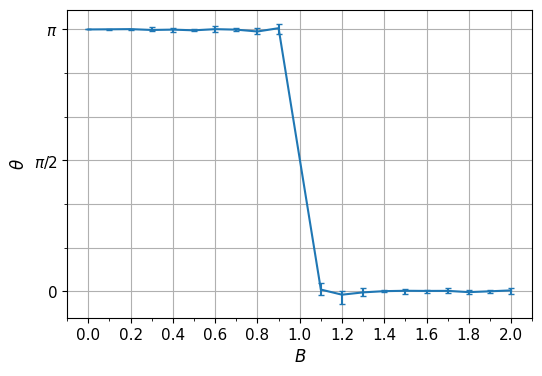

In [57]:
fig, ax = plt.subplots(figsize=(6,4))

plt.errorbar(
    b_params,
    mean_gauge_invariant_proj_rep_angle,
    yerr=error_gauge_invariant_proj_rep_angle,
    color='tab:blue',
    fmt='-',
    capsize=2
)

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)
ax.xaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

ax.set_yticks(
    np.linspace(0, np.pi, 3),
    labels=['$0$', '$\pi/2$', '$\pi$']
)

ax.set_yticks(
    [np.pi/6, np.pi/3, 2*np.pi/3, 5*np.pi/6],
    minor=True
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid(
    axis='y',
    which='both'
)
ax.grid(
    axis='x',
    which='major'
)

ax.set_ylabel(r'$\theta$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

fig.savefig(r'plots/proj_rep_angle_from_circ_bosonic.png', dpi=200)

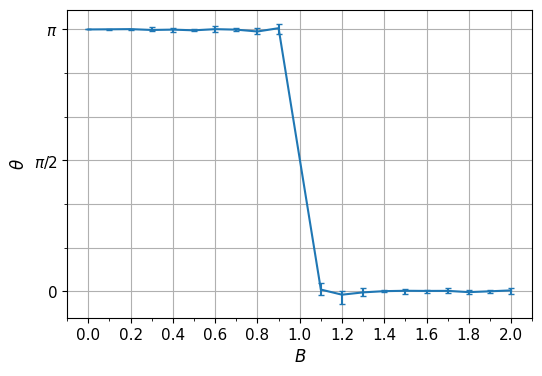

In [58]:
fig, ax = plt.subplots(figsize=(6,4))

plt.errorbar(
    b_params,
    mean_gauge_invariant_proj_rep_angle,
    yerr=error_gauge_invariant_proj_rep_angle,
    color='tab:blue',
    fmt='-',
    capsize=2
)

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)
ax.xaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

ax.set_yticks(
    np.linspace(0, np.pi, 3),
    labels=['$0$', '$\pi/2$', '$\pi$']
)

ax.set_yticks(
    [np.pi/6, np.pi/3, 2*np.pi/3, 5*np.pi/6],
    minor=True
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid(
    axis='y',
    which='both'
)
ax.grid(
    axis='x',
    which='major'
)

ax.set_ylabel(r'$\theta$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

fig.savefig(r'plots/proj_rep_angle_from_circ_bosonic.png', dpi=200)

In [76]:
with open(r'../../../make_plots/data/bosonic_variational_unitary_circuits/mean_proj_rep_angle.pkl', 'wb') as f:
    pickle.dump(mean_gauge_invariant_proj_rep_angle, f)

In [77]:
with open(r'../../../make_plots/data/bosonic_variational_unitary_circuits/error_proj_rep_angle.pkl', 'wb') as f:
    pickle.dump(error_gauge_invariant_proj_rep_angle, f)

In [59]:
gauge_invariant_proj_rep_real_phase = np.real(gauge_invariant_proj_rep_phase)
mean_gauge_invariant_proj_rep_real_phase = np.mean(gauge_invariant_proj_rep_real_phase, axis=(1,2))
max_gauge_invariant_proj_rep_real_phase = np.max(gauge_invariant_proj_rep_real_phase, axis=(1,2))
min_gauge_invariant_proj_rep_real_phase = np.min(gauge_invariant_proj_rep_real_phase, axis=(1,2))

min_max_gauge_invariant_proj_rep_real_phase = np.stack(
    [
        min_gauge_invariant_proj_rep_real_phase,
        max_gauge_invariant_proj_rep_real_phase
    ],
    axis=0
)

error_gauge_invariant_proj_rep_real_phase = (
    min_max_gauge_invariant_proj_rep_real_phase
    - mean_gauge_invariant_proj_rep_real_phase[np.newaxis, :]
)
error_gauge_invariant_proj_rep_real_phase = np.abs(error_gauge_invariant_proj_rep_real_phase)

In [60]:
np.max(error_gauge_invariant_proj_rep_real_phase)

0.008796700516767397

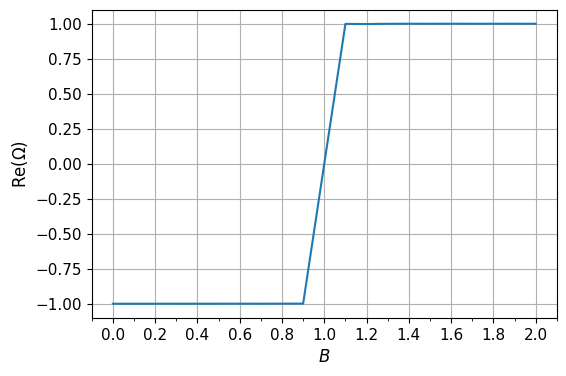

In [61]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    b_params,
    mean_gauge_invariant_proj_rep_real_phase,
    color='tab:blue'
)

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)
ax.xaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

"""
ax.set_yticks(
    np.linspace(0, np.pi, 3),
    labels=['$0$', '$\pi/2$', '$\pi$']
)

ax.set_yticks(
    [np.pi/6, np.pi/3, 2*np.pi/3, 5*np.pi/6],
    minor=True
)
"""

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid(
    axis='y',
    which='both'
)
ax.grid(
    axis='x',
    which='major'
)

ax.set_ylabel(r'Re$(\Omega)$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

fig.savefig(r'plots/proj_rep_real_phase_from_circ_bosonic.png', dpi=200)

# Scores

In [62]:
scores = list()
for t in b_params:

    scores.append([boundary_operator_scores[(t, i)] for i in [1,2,3]])

scores = np.array(scores)

In [63]:
overlaps = np.sqrt(1-scores)

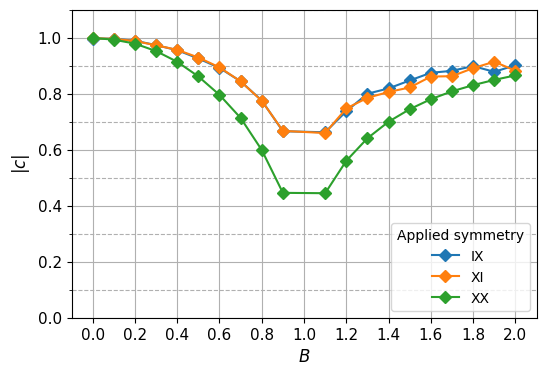

In [64]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.plot(
        b_params,
        overlaps[:, j],
        color=col,
        label = label,
        marker='D'
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

ax.yaxis.set_minor_locator(
    matplotlib.ticker.MultipleLocator(0.1)
)

#ax.set_yscale('log')
ax.set_ylim(bottom=0, top=1.1)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=11
)

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c \vert$', fontsize=12)
ax.set_xlabel('$B$', fontsize=12)

ax.legend(loc='lower right', title='Applied symmetry')

#fig.suptitle(r'Final cost $L$ with symmetry $g$ as a function of $B$')

fig.savefig(r'plots/overlaps_from_circ_bosonic.png', dpi=200)

In [75]:
with open(r'../../../make_plots/data/bosonic_variational_unitary_circuits/overlaps.pkl', 'wb') as f:
    pickle.dump(overlaps, f)

# Conclusions

It works!